## ECUACIÓN DE SCHRÖDINGER INDEPENDIENTE DEL TIEMPO

Esta ecuación tiene la forma:

$E\psi = -\frac{\hbar^2}{2m}\frac{d^2}{dx^2} \psi +\hat{v}(x)\psi$

Y si nos damos cuenta esta ecuación tiene la forma de un problema de Sturm-Liouville regular, el cual tiene la forma:

$\mathcal{L}_{SL} = -\frac{1}{w(x)}[\frac{d}{dx}(p(x)\frac{d}{dx}) + q(x)]$

Por tener la forma de un probelam de Sturm-Liouville regular tiene las siguientes propiedades:

-Existe un cojunto de inifitos auto-valores reales $E_0 < E_1 <...<...$ con un auto-valor mínimo llamado $E_0$

-Las respectivas auto-funciones $\psi_0 , \psi_1 , ...$ forman un cojunto completo, es decir, cualquier función suave puede ser escrita como una combinación lineal de estas autofunciones $f(x) = \sum_n C_n\psi_n$

-Las auto-funciones forman un cojunto ortonormal, es decir se cumple que: $\int \psi_n \psi_m = \delta_{nm}$

## DESARROLLO MATEMÁTICO

Vamos a asegurarnos de trabajar con cantidades adimensionales, entonces escogemos unidades tales que $\hbar = 1$ y hacemos el cambio de variable $u = x/L$ de esta forma la ecuación de Schrödinger sería:

$\frac{-1}{2}\frac{d^2}{du^2}\phi_n + mL^2V(u)\phi_n = E_n\phi_n$

De esta forma también tenemos las siguientes condiciones de frontera:

$\phi_n(0)=\phi_n(1) = 0$

## MODELADO NUMÉRICO

Vamos a usar diferencias finitas de segundo orden para resolver esta ecuación, de este método sabemos que la segunda derivada se puede escribir como:

$\frac{d^2\phi}{du^2} \sim \frac{\phi_{j+1}-2\phi_j + \phi_{j-1}}{\triangle u^2}$ tal que:$\phi_j = \phi(j\triangle u)$

Entonces nuestra ecuación se puede escribir como:

$\frac{-1}{2}\frac{\phi_{j+1}^{n}-2\phi_j^{n} + \phi_{j-1}^{n}}{\triangle u^2}+ mL^2V_j(u)\phi^{n}_j = mL^2E_n\phi_j^{n}$
Reorganizando tenemos:

$\frac{-1}{2\triangle u^2}\phi^{n}_{j+1} + (\frac{1}{\triangle u^2} + mL^2V_j)\phi_j^{n} \frac{-1}{2\triangle u^2}\phi^{n}_{j-1} = mL^2E_n\phi_j^{(n)}$

Pero esto no es más que un largo sistema de ecuaciones lineales, las cuales podemos escribir como una matriz tri-diagonal, es decir con 3 diagonales:

$$ \begin{bmatrix}\frac{1}{\Delta u^2}+mL^2V_1 & -\frac{1}{2 \Delta u^2} &   0 & 0...\\ -\frac{1}{2 \Delta u^2} & \frac{1}{\Delta u^2}+mL^2V_2 & -\frac{1}{2 \Delta u^2} & 0... \\ ...& ... & ... & -\frac{1}{2 \Delta u^2}\\...0 & 0 & -\frac{1}{2 \Delta u^2} & \frac{1}{\Delta u^2}+mL^2V_{N-1} \\ \end{bmatrix} \begin{bmatrix} \phi_1 \\ \phi_2 \\ ... \\ \phi_{N-1} \end{bmatrix} = mL^2 E \begin{bmatrix} \phi_1 \\ \phi_2 \\ ... \\ \phi_{N-1} \end{bmatrix} $$

Y con condiciones: $\phi_0 = \phi_N = 0$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh_tridiagonal

In [22]:
N = 3000
du = 1/N
u = np.linspace(0,10,N+1)

In [23]:
def pot(u):
    #return 1000*np.exp(-(u-0.7)**2/(2*0.05**2)) 
    #return 0*u
    return 1000*(u-1/2)**2 #Escogemos el escalar grande o pequeño dependiendo qué tan encerrado lo querramos
    #return np.exp(-(u-0.4)**2/(2*0.007**2)) 

In [24]:
d = 1/du**2 + pot(u)[1:-1] #Diagonal principal
e = -1/(2*du**2)*np.ones(len(d)-1) #diagonales adyacentes

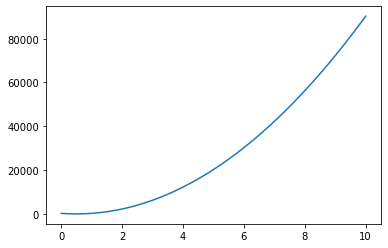

In [25]:
plt.plot(u , pot(u))

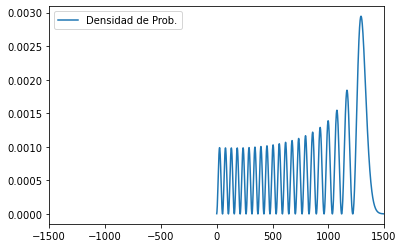

In [28]:
w , v = eigh_tridiagonal(d,e)
plt.plot((v.T[20]**2) , label = 'Densidad de Prob.')
plt.xlim([-1500 , 1500])
#plt.plot(v.T[1]**2)
#plt.plot(v.T[1])
#plt.plot(v.T[2]**2)
#plt.plot(v.T[3]**2)
plt.legend()

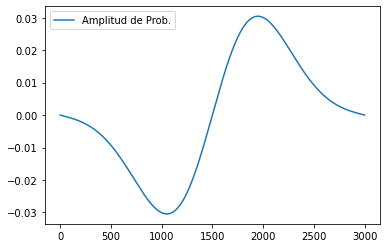

In [13]:
plt.plot(v.T[1] , label = 'Amplitud de Prob.')
plt.legend()

<BarContainer object of 11 artists>

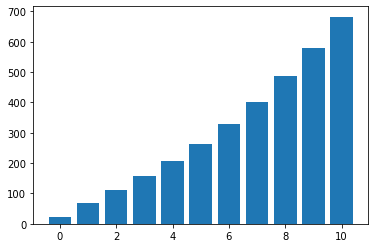

In [11]:
plt.bar(np.arange(0,11,1) , w[0:11])